# 2. Modeling: Cardiovascular Disease Prediction

## 2.1 Objective of the Modeling Stage

In this notebook, the goal is to build and evaluate machine learning models to predict the presence of cardiovascular disease using clinical, anthropometric, and lifestyle-related variables.

The modeling stage builds on the cleaned dataset generated during the exploratory data analysis phase and focuses on establishing a reproducible baseline workflow, comparing candidate models, and identifying the most informative predictors.

## 2.2 Load Processed Data

The cleaned dataset generated in the EDA stage is loaded from the processed data folder. This ensures that the modeling workflow is independent from the exploratory notebook and can be reproduced without re-running the full EDA pipeline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("../data/processed/cardio_clean.csv")

In [3]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,age_group
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50.391781,"[50, 55)"
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55.419178,"[55, 60)"
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51.663014,"[50, 55)"
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48.282192,"[45, 50)"
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47.873973,"[45, 50)"


## 2.3 Initial Data Check

Before modeling, the dataset is briefly inspected to confirm its shape, column names, data types, and target distribution. This step helps ensure that the exported processed dataset is consistent and ready for machine learning. 

### 2.3.1 Dataset shape

In [4]:
df.shape

(68647, 15)

### 2.3.2 Column overview

In [5]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years',
       'age_group'],
      dtype='object')

### 2.3.3 Data types

Understanding the data types of each variable is important before building machine learning models. This step helps identify categorical and numerical features and ensures that variables are represented in a format suitable for modeling.

In [ ]:
pd.DataFrame({"dtype": df.dtypes, "unique_values": df.nunique()})

,dtype,unique_values
id,int64,68647
age,int64,8064
gender,int64,2
height,int64,73
weight,float64,274
ap_hi,int64,109
ap_lo,int64,87
cholesterol,int64,3
gluc,int64,3
smoke,int64,2


Most variables in the dataset are numerical. However, several variables represent categorical information encoded as integers, including gender, cholesterol level, glucose level, smoking status, alcohol consumption, and physical activity.

These variables will later be treated as categorical features during the preprocessing stage.

### 2.3.4 Target distribution check

Before training machine learning models, it is important to examine the distribution of the target variable. This helps identify potential class imbalance, which may influence model performance and evaluation strategies.

In [7]:
df["cardio"].value_counts()

cardio
0    34688
1    33959
Name: count, dtype: int64

In [8]:
df["cardio"].value_counts(normalize=True)

cardio
0    0.50531
1    0.49469
Name: proportion, dtype: float64

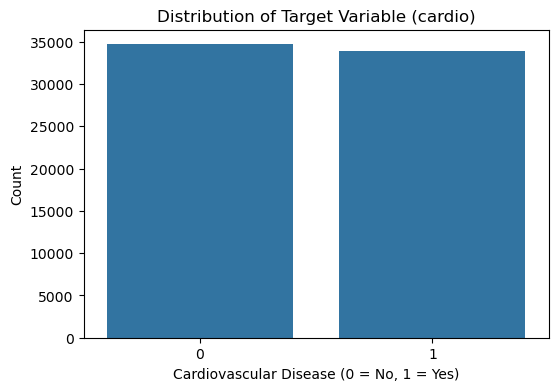

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(x="cardio", data=df)

plt.title("Distribution of Target Variable (cardio)")
plt.xlabel("Cardiovascular Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

The target variable is relatively balanced, with a similar number of observations for both classes. This reduces the risk of strong class imbalance affecting model training and evaluation, allowing standard classification metrics such as accuracy, precision, recall, and ROC-AUC to be used reliably.

The target variable for this project is `cardio`, where 0 indicates the absence of cardiovascular disease and 1 indicates its presence. The modeling task is therefore a binary classification problem.

## 2.4 Feature Selection Strategy

Not all columns in the dataset should necessarily be used as predictors. In this section, the input features are defined and variables that should not be used for modeling, such as identifiers, are excluded.

This step also clarifies whether derived variables created during EDA, such as age in years or BMI, will be included in the modeling dataset.

### 2.4.1 Variables excluded from modeling

In [10]:
df = df.drop(columns=["id", "age", "age_group"])

### 2.4.2 Candidate predictor variables

The remaining variables represent the main candidate predictors for cardiovascular disease. These include demographic, anthropometric, clinical, and lifestyle-related variables that may provide useful information for classification.

At this stage, the dataset retains the original predictors that are considered relevant for modeling. Additional derived variables will be created in the feature engineering section.

In [11]:
list(df.columns)

['gender',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'cardio',
 'age_years']

The candidate predictors can be grouped into four broad categories:

- **Demographic variables:** age_years, gender  
- **Anthropometric variables:** height, weight  
- **Clinical variables:** ap_hi, ap_lo, cholesterol, gluc  
- **Lifestyle variables:** smoke, alco, active  

These groups will be useful later when defining the preprocessing pipeline for numerical and categorical features.

## 2.5 Feature Engineering

In addition to the primary derived variables, a small set of optional features can be explored to capture potentially relevant physiological relationships. These variables are not strictly necessary but may provide additional predictive signal for the models.

The goal is to incorporate simple domain-inspired transformations without introducing unnecessary complexity.

### 2.5.1 Creating Body Mass Index (BMI)

In [12]:
 df["BMI]"] = df["weight"] / (df["height"] / 100) ** 2

### 2.5.2 Pulse Preassure

Pulse pressure is calculated as the difference between systolic and diastolic blood pressure.

It represents the force generated by the heart during each contraction and can provide additional information about vascular health. Higher pulse pressure values have been associated with increased arterial stiffness and cardiovascular risk in clinical studies.

Including pulse pressure as a derived feature may therefore help capture information that is not fully represented by systolic and diastolic blood pressure separately.

In [13]:
df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]


In [14]:
df[["ap_hi", "ap_lo", "pulse_pressure"]].head()

,ap_hi,ap_lo,pulse_pressure
0,110,80,30
1,140,90,50
2,130,70,60
3,150,100,50
4,100,60,40


### 2.5.3 Mean Arterial Pressure (Optional)

In [15]:
# Mean Arterial Pressure (optional)
df["MAP"] = (2 * df["ap_lo"] + df["ap_hi"]) / 3

Mean arterial pressure (MAP) provides an estimate of the average arterial pressure throughout the cardiac cycle and may offer additional information beyond systolic and diastolic measurements alone.

### 2.5.4 Optional Feature Exploration: Hypertension Indicator

In [16]:
hypertension = (df["ap_hi"] >= 140).astype(int)

A binary hypertension indicator can be derived from systolic blood pressure values using common clinical thresholds (e.g., systolic blood pressure ≥ 140 mmHg).

However, this feature is not included in the final modeling dataset because it does not introduce new information beyond the existing blood pressure measurements. Since systolic and diastolic pressure are already present in the dataset, the models are able to learn similar decision boundaries directly from these variables.

The indicator is briefly examined below for illustrative purposes but will not be retained as a predictor to avoid redundant features.

In [17]:
hypertension.value_counts(normalize=True)

ap_hi
0    0.731015
1    0.268985
Name: proportion, dtype: float64

In [18]:
pd.crosstab(hypertension, df["cardio"], normalize="index")

cardio,0,1
ap_hi,,
0,0.631262,0.368738
1,0.163011,0.836989


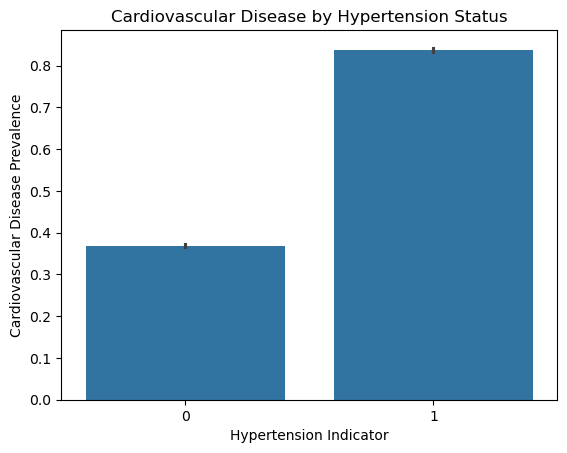

In [19]:
sns.barplot(x=hypertension, y=df["cardio"])

plt.xlabel("Hypertension Indicator")
plt.ylabel("Cardiovascular Disease Prevalence")
plt.title("Cardiovascular Disease by Hypertension Status")

plt.show()


### 2.5.5 Relationship Between Age, Blood Pressure and Cardiovasculas Risk

A binary hypertension indicator can be derived from systolic blood pressure values using common clinical thresholds (e.g., systolic blood pressure ≥ 140 mmHg).

However, this feature is not included in the final modeling dataset because it does not introduce new information beyond the existing blood pressure measurements. Since systolic and diastolic pressure are already present in the dataset, the models are able to learn similar decision boundaries directly from these variables.

The indicator is briefly examined below for illustrative purposes but will not be retained as a predictor to avoid redundant features.

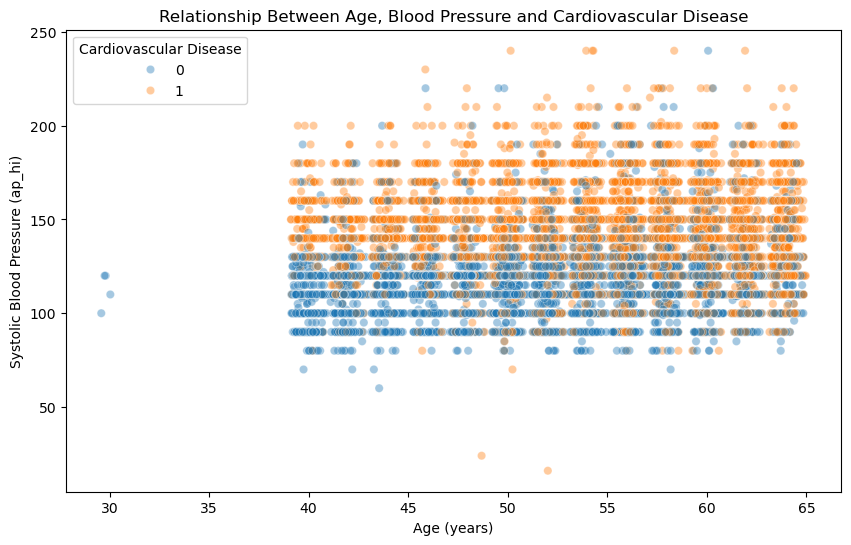

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="age_years", y="ap_hi", hue="cardio", alpha=0.4)

plt.title("Relationship Between Age, Blood Pressure and Cardiovascular Disease")
plt.xlabel("Age (years)")
plt.ylabel("Systolic Blood Pressure (ap_hi)")

plt.legend(title="Cardiovascular Disease")

plt.show()

The visualization suggests that higher systolic blood pressure and older age are associated with a greater prevalence of cardiovascular disease. 

While this plot does not establish causality, it highlights two of the most important physiological variables that may contribute to cardiovascular risk and reinforces their relevance for the predictive modeling stage.

### 2.5.6 Final modeling dataset

In [21]:
df.columns

Index(['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc',
       'smoke', 'alco', 'active', 'cardio', 'age_years', 'BMI]',
       'pulse_pressure', 'MAP'],
      dtype='object')

In [22]:
df.shape

(68647, 15)

## 2.6 Train-Test Split
### 2.6.1 Defining X and y
### 2.6.2 Splitting the dataset
### 2.6.3 Stratification strategy

## 2.7 Preprocessing Pipeline
### 2.7.1 Numerical and categorical feature groups
### 2.7.2 Encoding categorical variables
### 2.7.3 Scaling numerical variables
### 2.7.4 ColumnTransformer and reproducible preprocessing

## 2.8 Baseline Model
### 2.8.1 Choice of baseline model
### 2.8.2 Training the baseline model
### 2.8.3 Baseline performance on the test set

## 2.9 Evaluation Metrics
### 2.9.1 Accuracy
### 2.9.2 Precision, Recall, and F1-score
### 2.9.3 ROC-AUC
### 2.9.4 Confusion Matrix
### 2.9.5 Classification Report

## 2.10 Candidate Models
### 2.10.1 Logistic Regression
### 2.10.2 Decision Tree
### 2.10.3 Random Forest
### 2.10.4 Gradient Boosting or XGBoost (optional)
### 2.10.5 Model comparison strategy

## 2.11 Model Comparison
### 2.11.1 Summary table of model performance
### 2.11.2 Comparison across key metrics
### 2.11.3 Selecting the best-performing model

## 2.12 Hyperparameter Tuning
### 2.12.1 Tuning strategy
### 2.12.2 Cross-validation setup
### 2.12.3 Best hyperparameters
### 2.12.4 Tuned model performance

## 2.13 Feature Importance and Model Interpretation
### 2.13.1 Coefficient-based interpretation (for linear models)
### 2.13.2 Tree-based feature importance
### 2.13.3 Relationship with EDA findings

## 2.14 Error Analysis
### 2.14.1 False positives
### 2.14.2 False negatives
### 2.14.3 Possible reasons for misclassification

## 2.15 Final Model Assessment
## 2.16 Summary of Modeling Results
## 2.17 Next Steps